In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_ADO_corridas.csv',  encoding = 'utf-8-sig')
# dimension del dataframe
print('Forma', df.shape)
print('\nTipo de datos:')
print(df.dtypes)
print('\nNulos por columno:')
print(df.isnull().sum( ))
print("\nMuestra:")
df.head()

Forma (2520, 13)

Tipo de datos:
id_corrida           object
fecha                object
dia_semana           object
horario_salida       object
ruta                 object
terminal_origen      object
tipo_unidad          object
capacidad             int64
pasajeros           float64
ocupacion_pct       float64
precio_boleto       float64
ingresos_totales    float64
temporada            object
dtype: object

Nulos por columno:
id_corrida            0
fecha                 0
dia_semana            0
horario_salida        0
ruta                  0
terminal_origen       0
tipo_unidad          75
capacidad             0
pasajeros           126
ocupacion_pct         0
precio_boleto         0
ingresos_totales    101
temporada             0
dtype: int64

Muestra:


,id_corrida,fecha,dia_semana,horario_salida,ruta,terminal_origen,tipo_unidad,capacidad,pasajeros,ocupacion_pct,precio_boleto,ingresos_totales,temporada
0,ADO-00197,2024-08-07,Wednesday,06:00,CDMX-Cuernavaca,TAPO,ADO GL,48,26.0,54.2,220.0,5720.0,Alta
1,ADO-00987,06-03-2024,Wednesday,07:00,CDMX-Puebla,Poniente,ADO GL,48,47.0,97.9,280.0,13160.0,Baja
2,ADO-01091,12-07-2024,Friday,18:00,CDMX-cuernavaca,Observatorio,ADO GL,48,37.0,77.1,220.0,8140.0,Alta
3,ADO-00388,2024-03-19,Tuesday,18:00,CDMX - Pachuca,Norte,ADO GL,48,48.0,100.0,190.0,9120.0,Baja
4,ADO-02222,13-06-2024,Thursday,13:00,CDMX-Tlaxcala,Sur,Primera Plus,36,20.0,55.6,228.0,4560.0,Baja


In [2]:
print('\nNulos por columno:')
print(df.isnull().sum( ))


Nulos por columno:
id_corrida            0
fecha                 0
dia_semana            0
horario_salida        0
ruta                  0
terminal_origen       0
tipo_unidad          75
capacidad             0
pasajeros           126
ocupacion_pct         0
precio_boleto         0
ingresos_totales    101
temporada             0
dtype: int64


In [3]:
# Ver todas las variaciones de ruta
print("Rutas únicas antes de limpiar:")
print(df['ruta'].value_counts())

Rutas únicas antes de limpiar:
ruta
CDMX - Toluca          209
cdmx - puebla          199
CDMX - Pachuca         196
cdmx-queretaro         196
CDMX-Queretaro         191
CDMX-cuernavaca        189
CDMX-Querétaro         189
CDMX - Puebla          189
CDMX-Pachuca           188
CDMX-Cuernavaca        181
CDMX-Tlaxcala          176
CDMX-Toluca            172
CDMX-Puebla            169
  CDMX-Tlaxcala         10
  CDMX-Queretaro         7
  CDMX-cuernavaca        7
  CDMX-Querétaro         7
  CDMX - Pachuca         7
  CDMX-Pachuca           6
  CDMX - Toluca          6
  CDMX-Cuernavaca        5
  CDMX-Toluca            5
  CDMX - Puebla          4
  cdmx - puebla          4
  CDMX-Puebla            4
  cdmx-queretaro         4
Name: count, dtype: int64


In [4]:
# Paso 1: quitar espacios extremos y pasar a mayúsculas
df['ruta'] = df['ruta'].str.strip().str.upper()

# Paso 2: unificar separador (quitar espacios alrededor del guión)
df['ruta'] = df['ruta'].str.replace(' - ', '-', regex=False)

# Paso 3: corregir acento
df['ruta'] = df['ruta'].str.replace('QUERETARO', 'QUERÉTARO', regex=False)

# Verificar resultado
print("Rutas únicas después de limpiar:")
print(df['ruta'].value_counts())
print("\nTotal de rutas únicas:", df['ruta'].nunique())

Rutas únicas después de limpiar:
ruta
CDMX-QUERÉTARO     594
CDMX-PUEBLA        569
CDMX-PACHUCA       397
CDMX-TOLUCA        392
CDMX-CUERNAVACA    382
CDMX-TLAXCALA      186
Name: count, dtype: int64

Total de rutas únicas: 6


In [5]:
# Intentar múltiples formatos
def parsear_fecha(fecha_str):
    formatos = ['%Y-%m-%d', '%d/%m/%Y', '%d-%m-%Y', '%Y/%m/%d']
    for fmt in formatos:
        try:
            return pd.to_datetime(fecha_str, format=fmt)
        except:
            continue
    return pd.NaT

df['fecha'] = df['fecha'].astype(str).apply(parsear_fecha)

# Ver resultado
print("Fechas no parseadas:", df['fecha'].isna().sum())
print("\nMuestra:")
print(df[['fecha']].head(10))

Fechas no parseadas: 0

Muestra:
       fecha
0 2024-08-07
1 2024-03-06
2 2024-07-12
3 2024-03-19
4 2024-06-13
5 2024-12-10
6 2024-07-21
7 2024-04-14
8 2024-12-16
9 2024-04-13


In [6]:
df['anio']           = df['fecha'].dt.year
df['mes']            = df['fecha'].dt.month
df['mes_nombre']     = df['fecha'].dt.strftime('%B')
df['dia_num']        = df['fecha'].dt.dayofweek  # 0=lunes, 6=domingo
df['es_fin_semana']  = df['dia_num'].isin([5, 6]).astype(int)

print(df[['fecha', 'mes_nombre', 'dia_num', 'es_fin_semana']].head(8))

       fecha mes_nombre  dia_num  es_fin_semana
0 2024-08-07     August        2              0
1 2024-03-06      March        2              0
2 2024-07-12       July        4              0
3 2024-03-19      March        1              0
4 2024-06-13       June        3              0
5 2024-12-10   December        1              0
6 2024-07-21       July        6              1
7 2024-04-14      April        6              1


In [7]:
# Ver situación actual
print("Nulos antes de limpiar:")
print(df[['pasajeros', 'ingresos_totales', 'tipo_unidad']].isnull().sum())

# 1. Imputar pasajeros con mediana por ruta
df['pasajeros'] = df.groupby('ruta')['pasajeros'].transform(
    lambda x: x.fillna(x.median())
)

df['ingresos_totales'] = df['ingresos_totales'].fillna(
    df['pasajeros'] * df['precio_boleto']
)

# 3. Eliminar ingresos negativos — error de captura
df = df[df['ingresos_totales'] >= 0]

# 4. Eliminar ocupación imposible mayor a 100%
df = df[df['ocupacion_pct'] <= 100]

# 5. Eliminar duplicados
antes = len(df)
df = df.drop_duplicates()
print(f"\nDuplicados eliminados: {antes - len(df)}")

# 6. Eliminar inconsistencia: 0 pasajeros con ingresos > 0
inconsistentes = ((df['pasajeros'] == 0) & (df['ingresos_totales'] > 0)).sum()
df = df[~((df['pasajeros'] == 0) & (df['ingresos_totales'] > 0))]
print(f"Inconsistencias eliminadas: {inconsistentes}")

# Resultado final
print(f"\nDataset limpio: {len(df)} registros")
print("\nNulos después de limpiar:")
print(df[['pasajeros', 'ingresos_totales', 'tipo_unidad']].isnull().sum())

Nulos antes de limpiar:
pasajeros           126
ingresos_totales    101
tipo_unidad          75
dtype: int64

Duplicados eliminados: 20
Inconsistencias eliminadas: 12

Dataset limpio: 2465 registros

Nulos después de limpiar:
pasajeros            0
ingresos_totales     0
tipo_unidad         74
dtype: int64


In [8]:
df.to_csv('dataset_ADO_limpio.csv', index=False, encoding='utf-8-sig')
print("Dataset guardado correctamente")

Dataset guardado correctamente


In [15]:
# Ocupación promedio por ruta
print("=== OCUPACIÓN PROMEDIO POR RUTA ===")
ocupacion_ruta = df.groupby('ruta')['ocupacion_pct'].mean().sort_values(ascending=False).round(1)
print(ocupacion_ruta)

# Ingresos totales por ruta
print("\n=== INGRESOS TOTALES POR RUTA ===")
ingresos_ruta = df.groupby('ruta')['ingresos_totales'].sum().sort_values(ascending=False).round(0)
print(ingresos_ruta)

# Ocupación por temporada
print("\n=== OCUPACIÓN POR TEMPORADA ===")
print(df.groupby('temporada')['ocupacion_pct'].mean().round(1))

# Ruta con mayor y menor ocupación:
print("Ruta con mayor ocupación:", ocupacion_ruta.idxmax())
print("Ocupación:", ocupacion_ruta.max())

print("\nRuta con menor ocupación:", ocupacion_ruta.idxmin())
print("Ocupación:", ocupacion_ruta.min())


=== OCUPACIÓN PROMEDIO POR RUTA ===
ruta
CDMX-TLAXCALA      75.0
CDMX-QUERÉTARO     74.9
CDMX-PUEBLA        74.8
CDMX-CUERNAVACA    74.7
CDMX-TOLUCA        74.4
CDMX-PACHUCA       73.4
Name: ocupacion_pct, dtype: float64

=== INGRESOS TOTALES POR RUTA ===
ruta
CDMX-QUERÉTARO     5412368.0
CDMX-PUEBLA        4566380.0
CDMX-CUERNAVACA    2376319.0
CDMX-PACHUCA       2123564.0
CDMX-TOLUCA        2029860.0
CDMX-TLAXCALA      1284552.0
Name: ingresos_totales, dtype: float64

=== OCUPACIÓN POR TEMPORADA ===
temporada
Alta    75.1
Baja    74.2
Name: ocupacion_pct, dtype: float64
Ruta con mayor ocupación: CDMX-TLAXCALA
Ocupación: 75.0

Ruta con menor ocupación: CDMX-PACHUCA
Ocupación: 73.4


In [16]:
# Ocupación promedio por horario
print("=== OCUPACIÓN POR HORARIO ===")
ocupacion_hora = df.groupby('horario_salida')['ocupacion_pct'].mean().round(1)
print(ocupacion_hora.sort_values(ascending=False))

# Ocupación fin de semana vs entre semana
print("\n=== FIN DE SEMANA VS ENTRE SEMANA ===")
print(df.groupby('es_fin_semana')['ocupacion_pct'].mean().round(1))

# Ocupación por ruta y día de semana
print("\n=== OCUPACIÓN POR RUTA Y FIN DE SEMANA ===")
print(df.groupby(['ruta', 'es_fin_semana'])['ocupacion_pct'].mean().round(1).unstack())

=== OCUPACIÓN POR HORARIO ===
horario_salida
17:00    84.3
09:00    84.2
19:00    83.8
08:00    83.2
18:00    82.9
07:00    81.8
14:00    70.6
06:00    70.5
13:00    70.4
15:00    70.1
16:00    70.1
10:00    69.9
11:00    69.5
20:00    69.5
21:00    69.4
22:00    67.7
12:00    66.3
Name: ocupacion_pct, dtype: float64

=== FIN DE SEMANA VS ENTRE SEMANA ===
es_fin_semana
0    69.2
1    87.6
Name: ocupacion_pct, dtype: float64

=== OCUPACIÓN POR RUTA Y FIN DE SEMANA ===
es_fin_semana       0     1
ruta                       
CDMX-CUERNAVACA  69.7  87.7
CDMX-PACHUCA     68.2  87.2
CDMX-PUEBLA      70.2  86.8
CDMX-QUERÉTARO   69.1  89.4
CDMX-TLAXCALA    70.7  87.5
CDMX-TOLUCA      67.8  86.4


In [17]:
print("=== OCUPACIÓN POR RUTA, HORARIO Y DÍA ===")
tabla = df.groupby(['ruta', 'horario_salida', 'es_fin_semana'])['ocupacion_pct'].mean().round(1).unstack()
tabla.columns = ['Entre semana', 'Fin de semana']
print(tabla)

=== OCUPACIÓN POR RUTA, HORARIO Y DÍA ===
                                Entre semana  Fin de semana
ruta            horario_salida                             
CDMX-CUERNAVACA 06:00                   60.8           82.6
                07:00                   77.1           97.8
                08:00                   75.8           98.0
                09:00                   81.6           94.8
                10:00                   57.7           83.6
...                                      ...            ...
CDMX-TOLUCA     18:00                   72.4           97.6
                19:00                   78.9           96.1
                20:00                   63.0           83.2
                21:00                   65.1           82.6
                22:00                   60.3           81.9

[102 rows x 2 columns]


In [18]:
# Horarios con demanda insatisfecha (fin de semana >90%)
print("=== DEMANDA INSATISFECHA — FIN DE SEMANA >90% ===")
criticos_alta = df[
    (df['es_fin_semana'] == 1) & 
    (df['ocupacion_pct'] > 90)
].groupby(['ruta', 'horario_salida'])['ocupacion_pct'].mean().round(1)
print(criticos_alta.sort_values(ascending=False).head(15))

# Horarios con exceso de oferta (entre semana <65%)
print("\n=== EXCESO DE OFERTA — ENTRE SEMANA <65% ===")
criticos_baja = df[
    (df['es_fin_semana'] == 0) & 
    (df['ocupacion_pct'] < 65)
].groupby(['ruta', 'horario_salida'])['ocupacion_pct'].mean().round(1)
print(criticos_baja.sort_values().head(15))

=== DEMANDA INSATISFECHA — FIN DE SEMANA >90% ===
ruta             horario_salida
CDMX-CUERNAVACA  13:00             100.0
                 17:00             100.0
CDMX-PACHUCA     07:00             100.0
                 18:00             100.0
CDMX-TLAXCALA    16:00             100.0
CDMX-TOLUCA      10:00             100.0
CDMX-TLAXCALA    08:00             100.0
CDMX-PUEBLA      18:00             100.0
                 15:00             100.0
CDMX-PACHUCA     22:00             100.0
CDMX-TLAXCALA    14:00             100.0
CDMX-TOLUCA      18:00              99.6
CDMX-QUERÉTARO   18:00              99.3
                 07:00              99.3
                 09:00              99.3
Name: ocupacion_pct, dtype: float64

=== EXCESO DE OFERTA — ENTRE SEMANA <65% ===
ruta             horario_salida
CDMX-TLAXCALA    21:00             47.6
CDMX-PACHUCA     14:00             49.6
CDMX-TLAXCALA    10:00             50.8
CDMX-CUERNAVACA  16:00             50.9
CDMX-PUEBLA      16:00       

In [19]:
# Guardar hallazgos en Excel con dos hojas
with pd.ExcelWriter('reporte_ADO_hallazgos.xlsx') as writer:
    criticos_alta.reset_index().to_excel(writer, sheet_name='Demanda_Insatisfecha', index=False)
    criticos_baja.reset_index().to_excel(writer, sheet_name='Exceso_Oferta', index=False)

print("Reporte guardado correctamente")

Reporte guardado correctamente


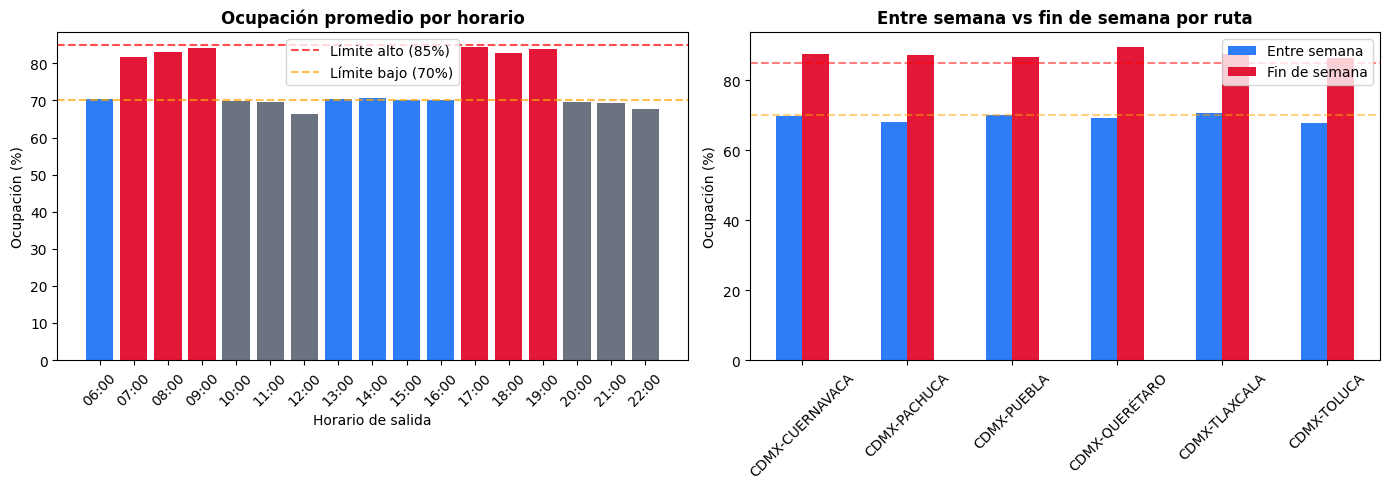

Gráfica guardada


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1 — Ocupación por horario
ocupacion_hora_ord = df.groupby('horario_salida')['ocupacion_pct'].mean().sort_index()
axes[0].bar(ocupacion_hora_ord.index, ocupacion_hora_ord.values, 
            color=['#E31837' if v > 80 else '#2E7CF6' if v > 70 else '#6B7280' 
                   for v in ocupacion_hora_ord.values])
axes[0].axhline(y=85, color='red', linestyle='--', alpha=0.7, label='Límite alto (85%)')
axes[0].axhline(y=70, color='orange', linestyle='--', alpha=0.7, label='Límite bajo (70%)')
axes[0].set_title('Ocupación promedio por horario', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horario de salida')
axes[0].set_ylabel('Ocupación (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Gráfica 2 — Entre semana vs fin de semana por ruta
ocupacion_semana = df.groupby(['ruta', 'es_fin_semana'])['ocupacion_pct'].mean().unstack()
ocupacion_semana.columns = ['Entre semana', 'Fin de semana']
ocupacion_semana.plot(kind='bar', ax=axes[1], color=['#2E7CF6', '#E31837'])
axes[1].axhline(y=85, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=70, color='orange', linestyle='--', alpha=0.5)
axes[1].set_title('Entre semana vs fin de semana por ruta', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Ocupación (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('grafica_ocupacion_ADO.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")